In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [2]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("/home/mohamed-ashraf/Desktop/projects/accelera/data/data.csv")

feature_cols = df.iloc[:, :-1].columns
X = df[feature_cols].values
labels = df["label"].values
y = df["label"].values

print(f"Vector type: {type(X[0])}")
print(f"Vector shape: {X[0].shape}")
print(f"First vector:\n{X[0]}")
print(f"First label:\n{y[0]}")

Vector type: <class 'numpy.ndarray'>
Vector shape: (40,)
First vector:
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         1.         0.
 0.         0.         0.         0.         1.         0.2
 0.         0.25       0.25       0.35643566 0.7128713  0.06930693
 0.42574257 0.7821782  0.         0.         0.         0.
 0.         0.         0.         0.         0.08       0.04
 0.4        0.05       0.05       0.        ]
First label:
parallel_for


In [4]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

Text(0.5, 1.0, 'Class Distribution')

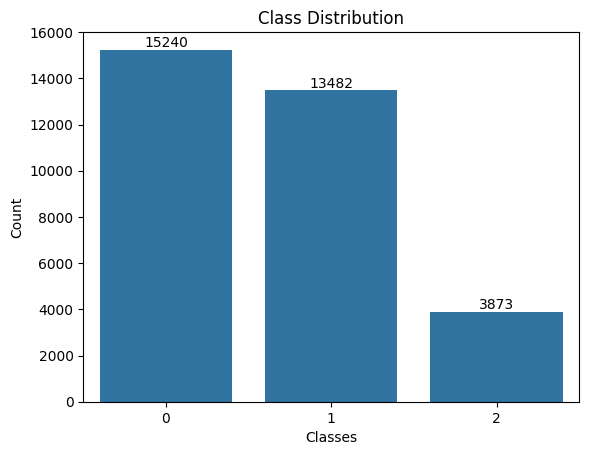

In [5]:
classes, count = np.unique(y, return_counts=True)
ax = sns.barplot(x=classes, y=count)

# Add count labels above each bar
for i, (cls, cnt) in enumerate(zip(classes, count)):
    ax.text(i, cnt, str(cnt), ha="center", va="bottom")

ax.set_xlabel("Classes")
ax.set_ylabel("Count")
ax.set_title("Class Distribution")

/home/mohamed-ashraf/Desktop/projects/env/lib/python3.12/site-packages/xgboost/core.py:160: UserWarning: [20:23:47] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "scale_pos_weight" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

        none       0.82      0.85      0.84      3048
parallel_for       0.86      0.81      0.83      2696
   reduction       0.79      0.82      0.80       775

    accuracy                           0.83      6519
   macro avg       0.82      0.83      0.83      6519
weighted avg       0.83      0.83      0.83      6519



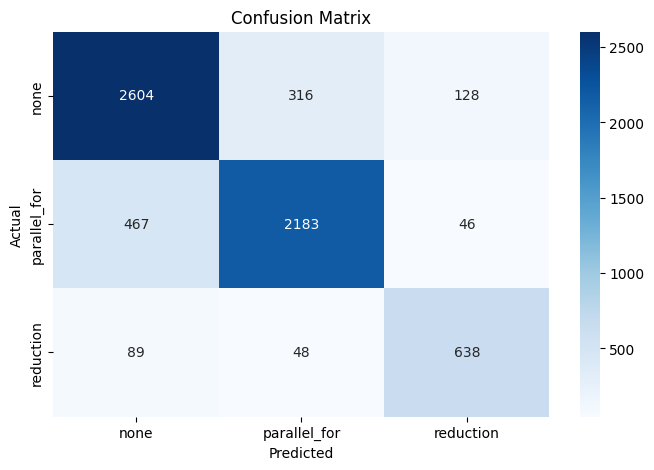

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=9,
    learning_rate=0.03,
    scale_pos_weight=3.0,
    random_state=42,
    tree_method="hist",
    device="cpu",
    n_jobs=-1,
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(
    classification_report(y_test, y_pred, target_names=label_encoder.classes_)
)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [7]:
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)